True parameters:
a = 2.0, b = 0.8

Least Squares estimate:
[1.94751409 0.80570996]

Maximum Likelihood estimate:
[1.94751409 0.80570996]

MAP estimate:
[1.9409147  0.80702861]


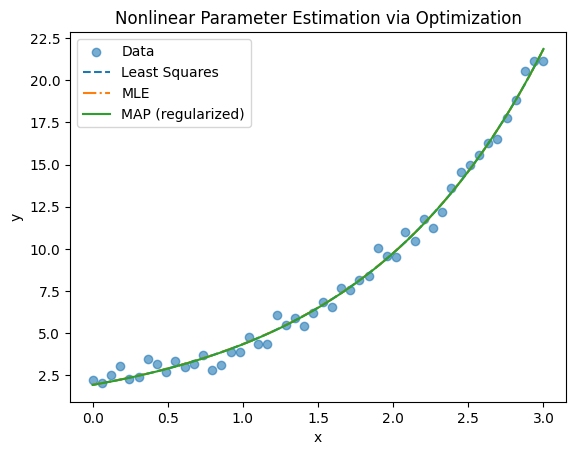

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -----------------------------
# 1. Generate synthetic data
# -----------------------------
np.random.seed(42)

n = 50
x = np.linspace(0, 3, n)

true_a = 2.0
true_b = 0.8
sigma = 0.5

noise = np.random.normal(0, sigma, size=n)
y = true_a * np.exp(true_b * x) + noise

# -----------------------------
# 2. Define model
# -----------------------------
def model(params, x):
    a, b = params
    return a * np.exp(b * x)

# -----------------------------
# 3. Least Squares Objective
# -----------------------------
def least_squares_objective(params, x, y):
    residuals = y - model(params, x)
    return np.sum(residuals**2)

# -----------------------------
# 4. Negative Log-Likelihood (MLE)
# -----------------------------
def neg_log_likelihood(params, x, y, sigma):
    residuals = y - model(params, x)
    return 0.5 * np.sum((residuals / sigma)**2)

# -----------------------------
# 5. Negative Log Posterior (MAP)
# -----------------------------
def neg_log_posterior(params, x, y, sigma, tau):
    # Likelihood term
    nll = neg_log_likelihood(params, x, y, sigma)
    
    # Gaussian prior: params ~ N(0, tau^2 I)
    prior = 0.5 * np.sum((params / tau)**2)
    
    return nll + prior

# -----------------------------
# 6. Run optimization
# -----------------------------
init_params = np.array([1.0, 0.1])  # initial guess

# Least Squares
res_ls = minimize(least_squares_objective, init_params, args=(x, y))
params_ls = res_ls.x

# MLE
res_mle = minimize(neg_log_likelihood, init_params, args=(x, y, sigma))
params_mle = res_mle.x

# MAP
tau = 1.0
res_map = minimize(neg_log_posterior, init_params, args=(x, y, sigma, tau))
params_map = res_map.x

# -----------------------------
# 7. Print results
# -----------------------------
print("True parameters:")
print(f"a = {true_a}, b = {true_b}\n")

print("Least Squares estimate:")
print(params_ls)

print("\nMaximum Likelihood estimate:")
print(params_mle)

print("\nMAP estimate:")
print(params_map)

# -----------------------------
# 8. Plot results
# -----------------------------
x_plot = np.linspace(0, 3, 100)

y_ls = model(params_ls, x_plot)
y_mle = model(params_mle, x_plot)
y_map = model(params_map, x_plot)

plt.scatter(x, y, label="Data", alpha=0.6)
plt.plot(x_plot, y_ls, label="Least Squares", linestyle="--")
plt.plot(x_plot, y_mle, label="MLE", linestyle="-.")
plt.plot(x_plot, y_map, label="MAP (regularized)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear Parameter Estimation via Optimization")
plt.show()